In [1]:
import sys
sys.path.append('../scripts')

from functions import * 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import copy
import wandb
import os
from tqdm.auto import tqdm
import ipywidgets

In [3]:
df_patch0 = load_data(0)

Data for Patch 0


Signal parameter: Rotated and Centered Proper Motion (DEC) μ_λ
Signal region factor = 1 and sideband region factor = 3
Signal parameter median = -13.147
Signal parameter standard deviation = 1.163
Signal Region Range: [-14.310, -11.984]
Sideband Region Range: [-16.636, -14.310) and (-11.984, -9.658]
Signal Region has 51528 stars, 307 stream and 51221 background.
Sideband Region has 118124 stars, 57 stream and 118067 background.
Outer Region has 2021540 stars, 14 stream and 2021526 background.


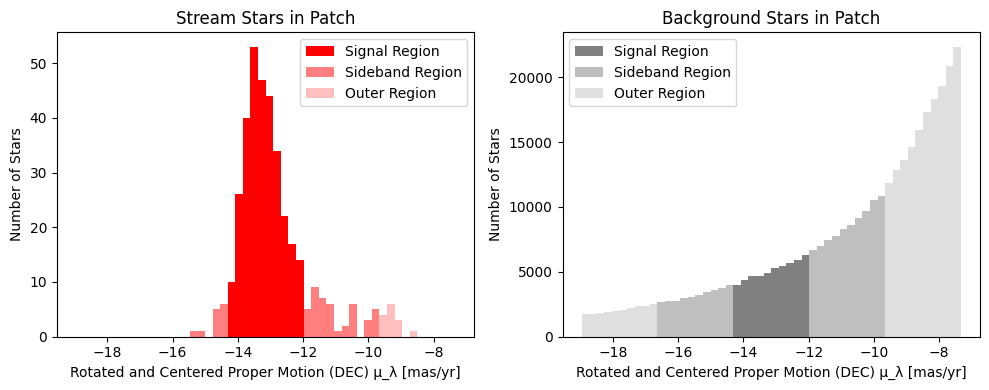

In [4]:
df_regions = signal_sideband(df_patch0, save_folder = None, pm_parameter='rotpmdec', sig_factor=1, sb_factor=3, bin_num=51)

In [5]:
import time
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

training_vars = ['b-r', 'g', 'rotra', 'rotdec', 'rotpmra']
train_x = df_regions[training_vars]
train_y = df_regions['region_label'].to_numpy()

scaler = StandardScaler() # scale data to standardize with mean of 0 and standard deviation of 1

train_x = scaler.fit_transform(train_x) # fit_transform called only on train data

        
# create tensors, datasets, and loaders
train_x_tensor = torch.tensor(np.array(train_x), dtype=torch.float32, device=device)
train_y_tensor = torch.tensor(train_y, dtype=torch.float32, device=device)

train_dataset = TensorDataset(train_x_tensor, train_y_tensor)

# swap in your real dataset object here
loader = DataLoader(train_dataset, batch_size=256, shuffle=True,
                     num_workers=0)

n_batches = 50
it = iter(loader)

t0 = time.perf_counter()
next(it)  # first batch includes worker startup cost
print(f"first batch: {time.perf_counter() - t0:.3f}s")

t0 = time.perf_counter()
for _ in range(n_batches):
    next(it)
elapsed = time.perf_counter() - t0

print(f"{n_batches} batches in {elapsed:.2f}s")
print(f"{elapsed/n_batches*1000:.1f} ms/batch, "
      f"{n_batches*256/elapsed:.0f} samples/s")

Using device: cuda
first batch: 0.012s
50 batches in 0.06s
1.3 ms/batch, 202279 samples/s


In [6]:


n_batches = 50
it = iter(loader)

t0 = time.perf_counter()
for i in range(n_batches):
    x_batch, y_batch = next(it)

    n_signal = (y_batch == 1).sum().item()
    n_sideband = (y_batch == 0).sum().item()
    has_nan = torch.isnan(x_batch).any().item()

    if i < 5:  # only print details for first few batches
        print(f"batch {i}: x{tuple(x_batch.shape)}, "
              f"signal={n_signal}, sideband={n_sideband}, nan={has_nan}")

elapsed = time.perf_counter() - t0
print(f"\n{n_batches} batches in {elapsed:.2f}s")
print(f"{elapsed/n_batches*1000:.1f} ms/batch, "
      f"{n_batches*256/elapsed:.0f} samples/s")

batch 0: x(256, 5), signal=89, sideband=167, nan=False
batch 1: x(256, 5), signal=69, sideband=187, nan=False
batch 2: x(256, 5), signal=71, sideband=185, nan=False
batch 3: x(256, 5), signal=81, sideband=175, nan=False
batch 4: x(256, 5), signal=81, sideband=175, nan=False

50 batches in 0.10s
2.0 ms/batch, 126872 samples/s


In [7]:
### full training function
def train_on_patch(patch_idx, scan_var, fid_cuts):
    print(f'Training Patch {patch_idx} with signal parameter {scan_var}...')
    df = load_data(patch_idx)
    df['patch'] = patch_idx
    plot_data(df, save_folder = f'check/plots/patch_{patch_idx}')
    df_regions = signal_sideband(df, save_folder = f'check/results/patch_{patch_idx}/{scan_var}', 
                               pm_parameter=scan_var, sig_factor=1, sb_factor=3)
    df_test_full = cwola_train(df_regions, pm_parameter=scan_var, dropout=0.2, k_folds=5, batch_size=10000,
                             lr=0.001, patience=30, epochs=50, trainval_loops=3, 
                             save_folder=f'check/results/patch_{patch_idx}/{scan_var}/training', wandbproj='patch0_50epochs')
    get_results(df_test_full, top_n=250, fid_cuts=fid_cuts, save_folder=f'check/results/patch_{patch_idx}/{scan_var}', patch_idx=patch_idx)

Training Patch 0 with signal parameter rotpmdec...
Data for Patch 0
Signal parameter: Rotated and Centered Proper Motion (DEC) μ_λ
Signal region factor = 1 and sideband region factor = 3
Signal parameter median = -13.147
Signal parameter standard deviation = 1.163
Signal Region Range: [-14.310, -11.984]
Sideband Region Range: [-16.636, -14.310) and (-11.984, -9.658]
Signal Region has 51528 stars, 307 stream and 51221 background.
Sideband Region has 118124 stars, 57 stream and 118067 background.
Outer Region has 2021540 stars, 14 stream and 2021526 background.
Proper Motion Parameter: Rotated and Centered Proper Motion (DEC) μ_λ
Using device: cuda
-----------------------------------------------
 
Test fold 0...
Validation fold 1...
Starting training loop 1


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /global/homes/a/alindell/.netrc.
wandb: Currently logged in as: alindell (alindell-university-of-wisconsin-madison) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

train batches:   0%|          | 0/11 [00:00<?, ?it/s]

train batches:   0%|          | 0/11 [00:00<?, ?it/s]

...

train batches:   0%|          | 0/11 [00:00<?, ?it/s]

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁███████████████████████████████████████
train_loss,█▃▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁██
val_loss,█▅▄▃▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▂▁▁▁▁▁▂▂▁▁▁▁▂▂▂▁▁▁▁▂
epoch,49
train_acc,0.69636
train_loss,0.61249
val_acc,0.69632
val_loss,0.614


Best validation loss for validation fold label 3 = 0.6132827997207642


test batches:   0%|          | 0/4 [00:00<?, ?it/s]

Test scores saved for test fold 4 val fold 3.
Averaging nn_scores for each star from the 4 best models...
Full test df with all stars saved!
Plotting after fiducial cuts...
Top 250 ranked stars: Purity = 34.00%
Top 250 ranked stars: Completeness = 28.72%


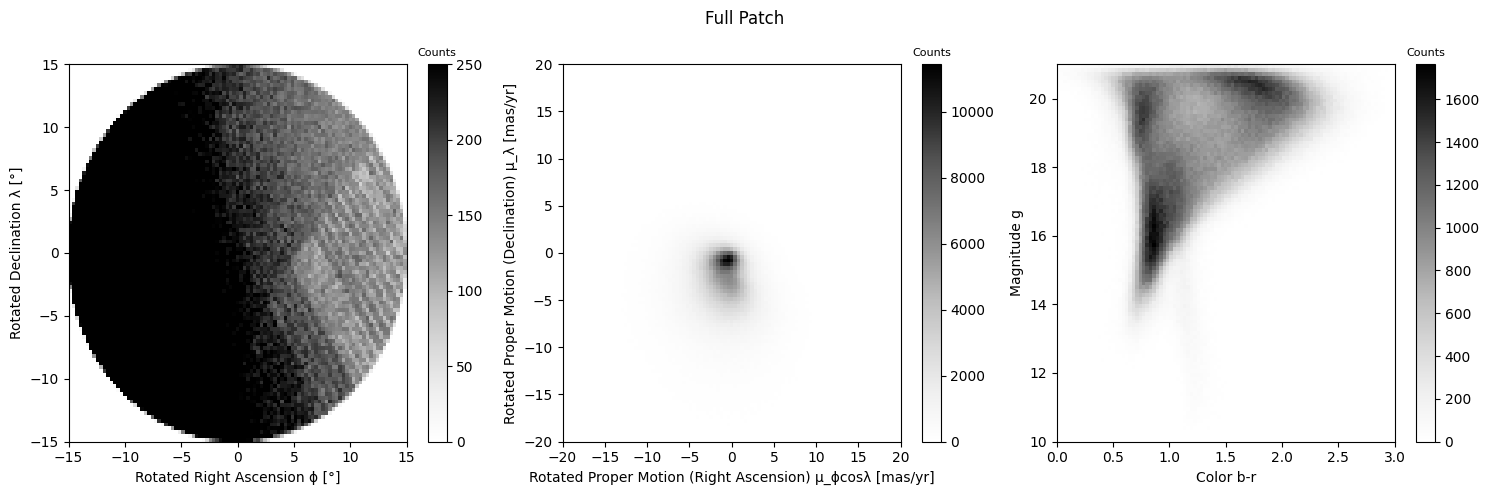

In [8]:
train_on_patch(patch_idx=0, scan_var='rotpmdec', fid_cuts=True)